# OTT 이탈 예측 모델
**원본 vs 전처리본 vs 피처추가본(v2) 3-way 비교**

타겟: repurchase (1=재결제, 0=이탈)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False
import warnings; warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

try:
    import lightgbm as lgb; HAS_LGB = True
except ImportError:
    HAS_LGB = False; print("LightGBM 없음 - pip install lightgbm")
try:
    import xgboost as xgb; HAS_XGB = True
except ImportError:
    HAS_XGB = False; print("XGBoost 없음 - pip install xgboost")
print("라이브러리 로드 완료")

라이브러리 로드 완료


## 1. 데이터 로드

In [14]:
raw  = pd.read_csv("../data/Membership.csv",            encoding="utf-8-sig")
proc = pd.read_csv("../data/Membership_processing.csv", encoding="utf-8-sig")
v2   = pd.read_csv("../data/Membership_v2.csv",         encoding="utf-8-sig")
print(f"원본:       {raw.shape}")
print(f"전처리본:   {proc.shape}")
print(f"피처추가본: {v2.shape}")

원본:       (18183, 15)
전처리본:   (17774, 29)
피처추가본: (17774, 53)


## 2. 전처리 함수

In [15]:
def prepare_raw(df):
    d = df.copy()
    d["repurchase"] = (d["repurchase"] == "O").astype(int)
    for col in ["promotion_yn", "is_churn_prevented"]:
        d[col] = (d[col] == "O").astype(int)
    d["is_user_verified"] = (d["is_user_verified"] == "Y").astype(int)
    drop = ["user_no", "product_cd", "reg_date", "end_date"]
    d = d.drop(columns=[c for c in drop if c in d.columns])
    for col in d.select_dtypes(include="object").columns:
        d[col] = LabelEncoder().fit_transform(d[col].astype(str))
    return d.fillna(0)

def prepare_clean(df):
    d = df.copy()
    drop = ["user_no", "product_cd", "reg_date", "end_date"]
    d = d.drop(columns=[c for c in drop if c in d.columns])
    for col in d.select_dtypes(include="object").columns:
        if col != "repurchase":
            d[col] = LabelEncoder().fit_transform(d[col].astype(str))
    return d.fillna(0)

raw_ready  = prepare_raw(raw)
proc_ready = prepare_clean(proc)
v2_ready   = prepare_clean(v2)

X_raw,  y_raw  = raw_ready.drop(columns="repurchase"),  raw_ready["repurchase"]
X_proc, y_proc = proc_ready.drop(columns="repurchase"), proc_ready["repurchase"]
X_v2,   y_v2   = v2_ready.drop(columns="repurchase"),   v2_ready["repurchase"]

print(f"원본       피처: {X_raw.shape[1]}개")
print(f"전처리본   피처: {X_proc.shape[1]}개")
print(f"피처추가본 피처: {X_v2.shape[1]}개")

원본       피처: 10개
전처리본   피처: 24개
피처추가본 피처: 48개


In [16]:
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_raw,  y_raw,  test_size=0.2, random_state=42, stratify=y_raw)
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(X_proc, y_proc, test_size=0.2, random_state=42, stratify=y_proc)
Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(X_v2,   y_v2,   test_size=0.2, random_state=42, stratify=y_v2)
print(f"원본       Train {Xr_tr.shape[0]} / Test {Xr_te.shape[0]}")
print(f"전처리본   Train {Xp_tr.shape[0]} / Test {Xp_te.shape[0]}")
print(f"피처추가본 Train {Xv_tr.shape[0]} / Test {Xv_te.shape[0]}")

원본       Train 14546 / Test 3637
전처리본   Train 14219 / Test 3555
피처추가본 Train 14219 / Test 3555


## 3. 모델 학습

In [18]:
from sklearn.metrics import precision_score, recall_score, average_precision_score

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except ImportError:
    HAS_CAT = False

def get_models():
    m = [
        ("Logistic Regression", Pipeline([("sc", StandardScaler()), ("lr", LogisticRegression(max_iter=1000, random_state=42))])),
        ("Random Forest",       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        ("Gradient Boosting",   GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ]
    if HAS_LGB: m.append(("LightGBM", lgb.LGBMClassifier(n_estimators=300, random_state=42, verbose=-1)))
    if HAS_XGB: m.append(("XGBoost",  xgb.XGBClassifier(n_estimators=300, random_state=42, eval_metric="logloss", verbosity=0)))
    if HAS_CAT: m.append(("CatBoost", CatBoostClassifier(iterations=300, random_seed=42, verbose=0)))
    return m

def calc_metrics(y_true, y_pred, y_prob):
    return {
        "ROC-AUC":   roc_auc_score(y_true, y_prob),
        "PR-AUC":    average_precision_score(y_true, y_prob),
        "Accuracy":  accuracy_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
    }

def run_models(label, models, X_tr, y_tr, X_te, y_te):
    header = label + "  (Train " + str(len(X_tr)) + "행 / Test " + str(len(X_te)) + "행)"
    print()
    print("="*80)
    print(" " + header)
    print("="*80)
    fmt_h = "  {:<22}  {:<6}  {:>8}  {:>8}  {:>9}  {:>7}  {:>7}  {:>7}"
    fmt_r = "  {:<22}  {:<6}  {:>8.4f}  {:>8.4f}  {:>9.4f}  {:>7.4f}  {:>7.4f}  {:>7.4f}"
    print(fmt_h.format("모델", "구분", "Accuracy", "F1", "Precision", "Recall", "ROC-AUC", "PR-AUC"))
    print("  " + "-"*22 + "  " + "  ".join(["-"*6,"-"*8,"-"*8,"-"*9,"-"*7,"-"*7,"-"*7]))
    results = []
    for name, model in models:
        model.fit(X_tr, y_tr)
        tr = calc_metrics(y_tr, model.predict(X_tr), model.predict_proba(X_tr)[:,1])
        te = calc_metrics(y_te, model.predict(X_te), model.predict_proba(X_te)[:,1])
        gap  = tr["ROC-AUC"] - te["ROC-AUC"]
        flag = " << 과적합" if gap > 0.05 else ""
        print(fmt_r.format(name, "Train", tr["Accuracy"], tr["F1"], tr["Precision"], tr["Recall"], tr["ROC-AUC"], tr["PR-AUC"]))
        print(fmt_r.format("", "Test ", te["Accuracy"], te["F1"], te["Precision"], te["Recall"], te["ROC-AUC"], te["PR-AUC"])
              + "  Gap:{:+.4f}{}".format(gap, flag))
        print()
        results.append({"name": name, "tr": tr, "te": te,
            "AUC": te["ROC-AUC"], "Gap": gap, "model": model,
            "Accuracy": te["Accuracy"], "F1": te["F1"],
            "Precision": te["Precision"], "Recall": te["Recall"],
            "PR_AUC": te["PR-AUC"], "Train_AUC": tr["ROC-AUC"],
        })
    return results

results_raw  = run_models("원본",       get_models(), Xr_tr, yr_tr, Xr_te, yr_te)
results_proc = run_models("전처리본",   get_models(), Xp_tr, yp_tr, Xp_te, yp_te)
results_v2   = run_models("피처추가본", get_models(), Xv_tr, yv_tr, Xv_te, yv_te)


 원본  (Train 14546행 / Test 3637행)
  모델                      구분      Accuracy        F1  Precision   Recall  ROC-AUC   PR-AUC
  ----------------------  ------  --------  --------  ---------  -------  -------  -------
  Logistic Regression     Train     0.6746    0.7975     0.6740   0.9763   0.6149   0.7332
                          Test      0.6723    0.7957     0.6731   0.9728   0.6225   0.7454  Gap:-0.0076

  Random Forest           Train     0.8760    0.9095     0.8726   0.9497   0.9572   0.9778
                          Test      0.6338    0.7389     0.6940   0.7900   0.6039   0.7216  Gap:+0.3533 << 과적합

  Gradient Boosting       Train     0.6908    0.8023     0.6913   0.9557   0.6796   0.7884
                          Test      0.6857    0.7973     0.6911   0.9422   0.6667   0.7690  Gap:+0.0129

  LightGBM                Train     0.7418    0.8291     0.7327   0.9548   0.8025   0.8862
                          Test      0.6764    0.7855     0.6949   0.9032   0.6439   0.7532  Gap:+0

## 4. 성능 비교표 & 시각화

In [8]:
def to_df(results):
    return pd.DataFrame([{k:v for k,v in r.items() if k!="model"} for r in results]).rename(columns={"name":"모델"}).set_index("모델")

df_r = to_df(results_raw)
df_p = to_df(results_proc)
df_v = to_df(results_v2)

compare = df_r[["AUC"]].rename(columns={"AUC":"AUC_원본"})
compare["AUC_전처리"]  = df_p["AUC"]
compare["AUC_v2"]      = df_v["AUC"]
compare["향상_전처리"] = compare["AUC_전처리"] - compare["AUC_원본"]
compare["향상_v2"]     = compare["AUC_v2"]     - compare["AUC_원본"]
display(compare.style.highlight_max(subset=["AUC_원본","AUC_전처리","AUC_v2"], color="#c6efce").format("{:.4f}"))

,AUC_원본,AUC_전처리,AUC_v2,향상_전처리,향상_v2
모델,,,,,
Logistic Regression,0.6225,0.6488,0.6487,0.0263,0.0262
Random Forest,0.6039,0.6420,0.6469,0.0381,0.0430
Gradient Boosting,0.6667,0.6693,0.6632,0.0025,-0.0036
LightGBM,0.6439,0.6481,0.6532,0.0042,0.0094
XGBoost,0.6262,0.6136,0.6286,-0.0126,0.0024


## 4-1. 데이터셋별 Best Model 비교표

In [9]:
def show_best_summary(datasets):
    metrics = ["ROC-AUC", "PR-AUC", "Accuracy", "F1", "Recall", "Precision"]
    rows, index = [], []
    for label, results in datasets:
        best = max(results, key=lambda r: r["AUC"])
        row = {}
        for m in metrics:
            row[(m, "Train")] = best["tr"][m]
            row[(m, "Test")]  = best["te"][m]
        rows.append(row)
        index.append(label + " / " + best["name"])

    df = pd.DataFrame(rows, index=index)
    df.columns = pd.MultiIndex.from_tuples(df.columns)

    full_cols = []
    for m in metrics:
        full_cols += [(m,"Train"),(m,"comp_tr"),(m,"Test"),(m,"comp_te")]
    df2 = pd.DataFrame(index=df.index, columns=pd.MultiIndex.from_tuples(full_cols), dtype=float)

    for m in metrics:
        for i, idx in enumerate(df2.index):
            df2.at[idx, (m,"Train")] = df.at[idx, (m,"Train")]
            df2.at[idx, (m,"Test")]  = df.at[idx, (m,"Test")]
            if i == 0:
                df2.at[idx, (m,"comp_tr")] = float("nan")
                df2.at[idx, (m,"comp_te")] = float("nan")
            else:
                prev = list(df2.index)[i-1]
                df2.at[idx, (m,"comp_tr")] = df2.at[idx,(m,"Train")] - df2.at[prev,(m,"Train")]
                df2.at[idx, (m,"comp_te")] = df2.at[idx,(m,"Test")]  - df2.at[prev,(m,"Test")]

    val_cols = [(m,c) for m in metrics for c in ["Train","Test"]]
    cmp_cols = [(m,c) for m in metrics for c in ["comp_tr","comp_te"]]

    def cmp_style(v):
        if pd.isna(v): return "color: gray"
        if v > 0: return "color: green; font-weight: bold"
        if v < 0: return "color: red"
        return ""

    styled = (df2.style
        .format(lambda v: "-" if pd.isna(v) else f"{v:.4f}", subset=val_cols)
        .format(lambda v: "-" if pd.isna(v) else f"{v:+.4f}", subset=cmp_cols)
        .applymap(cmp_style, subset=cmp_cols)
        .set_properties(**{"text-align": "center", "font-size": "12px", "min-width": "70px"})
        .set_table_styles([
            {"selector": "th", "props": [("background-color","#2E75B6"),("color","white"),
                                         ("text-align","center"),("font-size","12px")]},
            {"selector": "tr:nth-child(odd)",  "props": [("background-color","#BDD7EE")]},
            {"selector": "tr:nth-child(even)", "props": [("background-color","#DEEAF1")]},
        ])
        .highlight_max(subset=val_cols, color="#C6EFCE")
    )
    display(styled)

show_best_summary([
    ("원본",       results_raw),
    ("전처리본",   results_proc),
    ("피처추가본", results_v2),
])


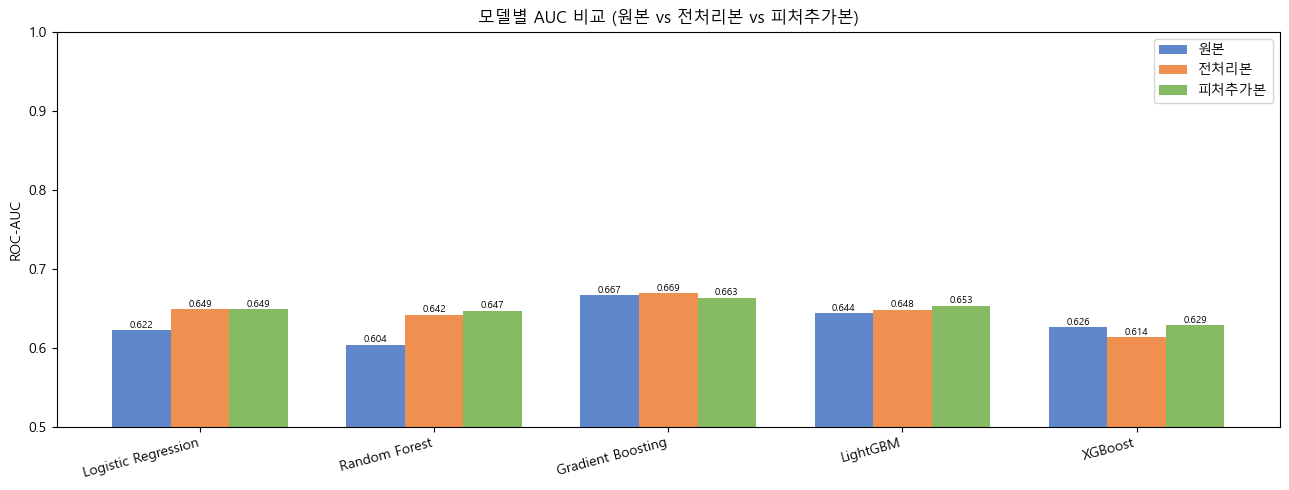

In [10]:
model_names = [r["name"] for r in results_raw]
auc_raw  = [r["AUC"] for r in results_raw]
auc_proc = [r["AUC"] for r in results_proc]
auc_v2   = [r["AUC"] for r in results_v2]
x = np.arange(len(model_names)); w = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x-w,   auc_raw,  w, label="원본",      color="#4472C4", alpha=0.85)
b2 = ax.bar(x,     auc_proc, w, label="전처리본",  color="#ED7D31", alpha=0.85)
b3 = ax.bar(x+w,   auc_v2,   w, label="피처추가본",color="#70AD47", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0.5, 1.0); ax.set_ylabel("ROC-AUC")
ax.set_title("모델별 AUC 비교 (원본 vs 전처리본 vs 피처추가본)"); ax.legend()
for bars, vals in [(b1,auc_raw),(b2,auc_proc),(b3,auc_v2)]:
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.003, f"{v:.3f}", ha="center", fontsize=7)
plt.tight_layout(); plt.show()

## 5. Confusion Matrix & 분류 리포트

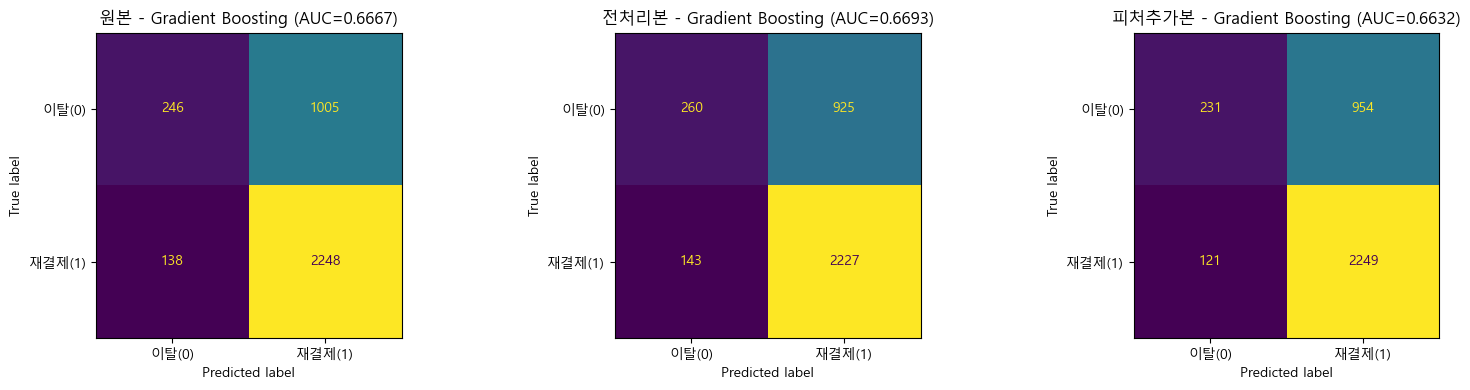

=== 원본 최고 모델: Gradient Boosting ===
              precision    recall  f1-score   support

          이탈       0.64      0.20      0.30      1251
         재결제       0.69      0.94      0.80      2386

    accuracy                           0.69      3637
   macro avg       0.67      0.57      0.55      3637
weighted avg       0.67      0.69      0.63      3637

=== 전처리본 최고 모델: Gradient Boosting ===
              precision    recall  f1-score   support

          이탈       0.65      0.22      0.33      1185
         재결제       0.71      0.94      0.81      2370

    accuracy                           0.70      3555
   macro avg       0.68      0.58      0.57      3555
weighted avg       0.69      0.70      0.65      3555

=== 피처추가본 최고 모델: Gradient Boosting ===
              precision    recall  f1-score   support

          이탈       0.66      0.19      0.30      1185
         재결제       0.70      0.95      0.81      2370

    accuracy                           0.70      3555
   macro avg   

In [11]:
best_raw  = max(results_raw,  key=lambda r: r["AUC"])
best_proc = max(results_proc, key=lambda r: r["AUC"])
best_v2   = max(results_v2,   key=lambda r: r["AUC"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, best, X_te, y_te, label in [
    (axes[0], best_raw,  Xr_te, yr_te, "원본"),
    (axes[1], best_proc, Xp_te, yp_te, "전처리본"),
    (axes[2], best_v2,   Xv_te, yv_te, "피처추가본"),
]:
    y_pred = best["model"].predict(X_te)
    ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred), display_labels=["이탈(0)","재결제(1)"]).plot(ax=ax, colorbar=False)
    nm = best["name"]; au = best["AUC"]
    ax.set_title(f"{label} - {nm} (AUC={au:.4f})")
plt.tight_layout(); plt.show()

for results, X_te, y_te, label in [
    (results_raw,  Xr_te, yr_te, "원본"),
    (results_proc, Xp_te, yp_te, "전처리본"),
    (results_v2,   Xv_te, yv_te, "피처추가본"),
]:
    best = max(results, key=lambda r: r["AUC"])
    nm = best["name"]
    print(f"=== {label} 최고 모델: {nm} ===")
    print(classification_report(y_te, best["model"].predict(X_te), target_names=["이탈","재결제"]))

## 6. Feature Importance (전처리본 최고 모델)

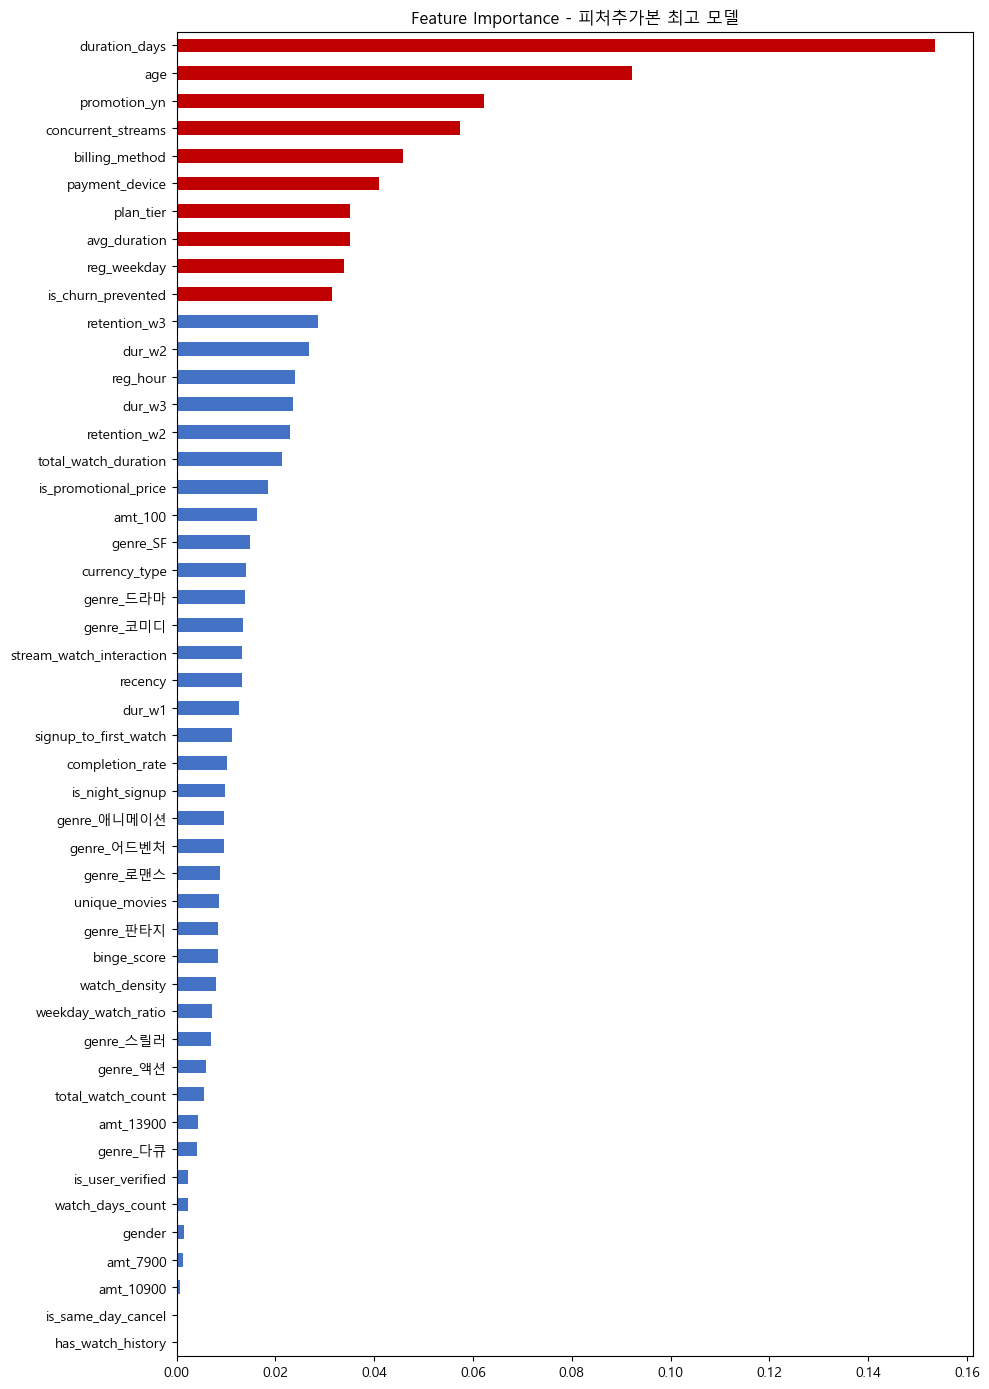

Top 15 피처:
duration_days         0.153624
age                   0.092268
promotion_yn          0.062135
concurrent_streams    0.057283
billing_method        0.045843
payment_device        0.041069
plan_tier             0.035118
avg_duration          0.035110
reg_weekday           0.033865
is_churn_prevented    0.031446
retention_w3          0.028720
dur_w2                0.026907
reg_hour              0.023994
dur_w3                0.023484
retention_w2          0.023024
dtype: float64


In [12]:
m = best_v2["model"]
if hasattr(m, "named_steps"): m = list(m.named_steps.values())[-1]

if hasattr(m, "feature_importances_"):
    fi = pd.Series(m.feature_importances_, index=X_v2.columns).sort_values(ascending=True)
    colors = ["#c00000" if v >= fi.quantile(0.8) else "#4472C4" for v in fi.values]
    fig, ax = plt.subplots(figsize=(10, 14))
    fi.plot(kind="barh", ax=ax, color=colors)
    ax.set_title("Feature Importance - 피처추가본 최고 모델")
    plt.tight_layout(); plt.show()
    print("Top 15 피처:")
    print(fi.sort_values(ascending=False).head(15))
elif hasattr(m, "coef_"):
    fi = pd.Series(np.abs(m.coef_[0]), index=X_v2.columns).sort_values(ascending=True)
    fi.plot(kind="barh", figsize=(10, 14), title="Coefficient 절댓값")
    plt.tight_layout(); plt.show()

## 7. 5-Fold 교차검증

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for results, X, y, label in [
    (results_raw,  X_raw,  y_raw,  "원본"),
    (results_proc, X_proc, y_proc, "전처리본"),
    (results_v2,   X_v2,   y_v2,   "피처추가본"),
]:
    print(f"\n=== {label} 5-Fold CV AUC ===")
    for r in results:
        s = cross_val_score(r["model"], X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
        nm = r["name"]
        print(f"  {nm:<25}  mean={s.mean():.4f}  std={s.std():.4f}")


=== 원본 5-Fold CV AUC ===
  Logistic Regression        mean=0.6161  std=0.0034
  Random Forest              mean=0.5851  std=0.0106
  Gradient Boosting          mean=0.6533  std=0.0027
  LightGBM                   mean=0.6289  std=0.0062
  XGBoost                    mean=0.6087  std=0.0074

=== 전처리본 5-Fold CV AUC ===
  Logistic Regression        mean=0.6404  std=0.0040
  Random Forest              mean=0.6332  std=0.0018
  Gradient Boosting          mean=0.6597  std=0.0037
  LightGBM                   mean=0.6379  std=0.0070
  XGBoost                    mean=0.6101  std=0.0033

=== 피처추가본 5-Fold CV AUC ===
  Logistic Regression        mean=0.6397  std=0.0048
  Random Forest              mean=0.6347  std=0.0052
  Gradient Boosting          mean=0.6548  std=0.0059
  LightGBM                   mean=0.6322  std=0.0017
  XGBoost                    mean=0.6083  std=0.0034


## 8. Optuna 하이퍼파라미터 튜닝 (원본 vs 전처리본 vs 피처추가본 비교)

In [14]:
import sys
!{sys.executable} -m pip install optuna -q


In [15]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_objective_lgb(X_tr, y_tr):
    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "num_leaves":        trial.suggest_int("num_leaves", 20, 200),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "random_state": 42, "verbose": -1,
        }
        model = lgb.LGBMClassifier(**params)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        return cross_val_score(model, X_tr, y_tr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    return objective

def make_objective_xgb(X_tr, y_tr):
    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma":             trial.suggest_float("gamma", 1e-8, 1.0, log=True),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "eval_metric": "logloss", "verbosity": 0, "random_state": 42,
        }
        model = xgb.XGBClassifier(**params)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        return cross_val_score(model, X_tr, y_tr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    return objective

# 피처추가본(v2)만, 200 trials
N_TRIALS = 200

optuna_results = []
print(f"[피처추가본] LightGBM ({N_TRIALS} trials)...")
study_lgb = optuna.create_study(direction="maximize")
study_lgb.optimize(make_objective_lgb(Xv_tr, yv_tr), n_trials=N_TRIALS, show_progress_bar=True)

print(f"[피처추가본] XGBoost  ({N_TRIALS} trials)...")
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(make_objective_xgb(Xv_tr, yv_tr), n_trials=N_TRIALS, show_progress_bar=True)

lgb_model = lgb.LGBMClassifier(**study_lgb.best_params, random_state=42, verbose=-1)
lgb_model.fit(Xv_tr, yv_tr)
xgb_model = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, eval_metric="logloss", verbosity=0)
xgb_model.fit(Xv_tr, yv_tr)

lgb_auc = roc_auc_score(yv_te, lgb_model.predict_proba(Xv_te)[:,1])
lgb_acc = accuracy_score(yv_te, lgb_model.predict(Xv_te))
xgb_auc = roc_auc_score(yv_te, xgb_model.predict_proba(Xv_te)[:,1])
xgb_acc = accuracy_score(yv_te, xgb_model.predict(Xv_te))

optuna_results.append({"데이터셋": "피처추가본",
    "LGB_AUC_CV": study_lgb.best_value, "LGB_AUC_Test": lgb_auc, "LGB_Acc": lgb_acc,
    "XGB_AUC_CV": study_xgb.best_value, "XGB_AUC_Test": xgb_auc, "XGB_Acc": xgb_acc,
    "lgb_model": lgb_model, "xgb_model": xgb_model, "label": "피처추가본",
    "X_te": Xv_te, "y_te": yv_te})
print(f"  LGB CV={study_lgb.best_value:.4f}  Test AUC={lgb_auc:.4f}  Acc={lgb_acc:.4f}")
print(f"  XGB CV={study_xgb.best_value:.4f}  Test AUC={xgb_auc:.4f}  Acc={xgb_acc:.4f}")

[피처추가본] LightGBM (200 trials)...


  0%|          | 0/200 [00:00<?, ?it/s]

[피처추가본] XGBoost  (200 trials)...


  0%|          | 0/200 [00:00<?, ?it/s]

  LGB CV=0.6600  Test AUC=0.6726  Acc=0.6903
  XGB CV=0.6603  Test AUC=0.6730  Acc=0.6878


,LGB AUC(CV),LGB AUC(Test),LGB Acc,XGB AUC(CV),XGB AUC(Test),XGB Acc
피처추가본,0.6600,0.6726,0.6903,0.6603,0.6730,0.6878


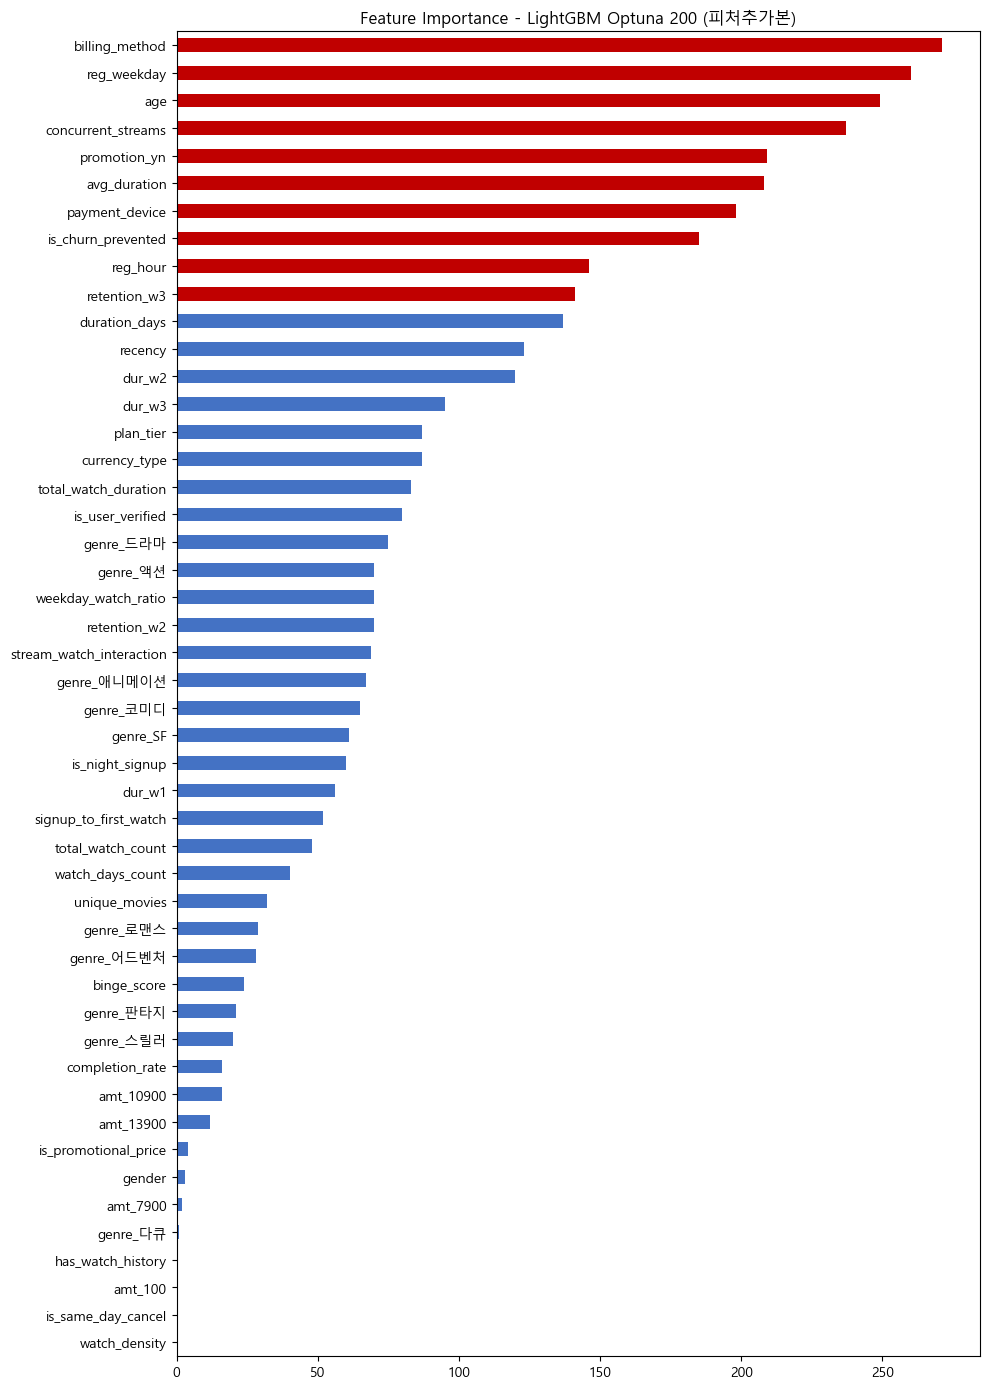

Top 10 피처:
billing_method        271
reg_weekday           260
age                   249
concurrent_streams    237
promotion_yn          209
avg_duration          208
payment_device        198
is_churn_prevented    185
reg_hour              146
retention_w3          141
dtype: int32


In [16]:
# 결과표
r = optuna_results[0]
df_opt = pd.DataFrame([{
    "LGB AUC(CV)": r["LGB_AUC_CV"], "LGB AUC(Test)": r["LGB_AUC_Test"], "LGB Acc": r["LGB_Acc"],
    "XGB AUC(CV)": r["XGB_AUC_CV"], "XGB AUC(Test)": r["XGB_AUC_Test"], "XGB Acc": r["XGB_Acc"],
}], index=["피처추가본"])
display(df_opt.style.highlight_max(color="#c6efce").format("{:.4f}"))

# Feature Importance
fi = pd.Series(lgb_model.feature_importances_, index=Xv_te.columns).sort_values(ascending=True)
colors = ["#c00000" if v >= fi.quantile(0.8) else "#4472C4" for v in fi.values]
fig, ax = plt.subplots(figsize=(10, 14))
fi.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Importance - LightGBM Optuna 200 (피처추가본)")
plt.tight_layout(); plt.show()
print("Top 10 피처:")
print(fi.sort_values(ascending=False).head(10))

## 9. CatBoost + Stacking 앙상블

In [17]:
import sys
!{sys.executable} -m pip install catboost -q

In [18]:
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

def encode_cat(X_tr, X_te):
    X_tr, X_te = X_tr.copy(), X_te.copy()
    for col in X_tr.select_dtypes(include="object").columns:
        le = LabelEncoder()
        X_tr[col] = le.fit_transform(X_tr[col].astype(str))
        X_te[col] = le.transform(X_te[col].astype(str))
    return X_tr, X_te

# 피처추가본(v2)만 사용
Xt, Xv = encode_cat(Xv_tr, Xv_te)
print("[피처추가본] CatBoost 학습 중...")

cat = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                          eval_metric="AUC", random_seed=42, verbose=0,
                          auto_class_weights="Balanced")
cat.fit(Xt, yv_tr)
cat_auc = roc_auc_score(yv_te, cat.predict_proba(Xv)[:,1])
cat_acc = accuracy_score(yv_te, cat.predict(Xv))
print(f"  CatBoost  AUC={cat_auc:.4f}  Acc={cat_acc:.4f}")

estimators = [
    ("lgb", lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                num_leaves=63, random_state=42, verbose=-1,
                                class_weight="balanced")),
    ("xgb", xgb.XGBClassifier(n_estimators=300, learning_rate=0.05,
                               max_depth=6, random_state=42, verbosity=0,
                               eval_metric="logloss",
                               scale_pos_weight=(yv_tr==0).sum()/(yv_tr==1).sum())),
    ("cat", CatBoostClassifier(iterations=300, learning_rate=0.05,
                               depth=6, random_seed=42, verbose=0,
                               auto_class_weights="Balanced")),
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, stack_method="predict_proba", n_jobs=-1,
)
print("[피처추가본] Stacking 학습 중...")
stack.fit(Xt, yv_tr)
stk_auc = roc_auc_score(yv_te, stack.predict_proba(Xv)[:,1])
stk_acc = accuracy_score(yv_te, stack.predict(Xv))
print(f"  Stacking  AUC={stk_auc:.4f}  Acc={stk_acc:.4f}")

[피처추가본] CatBoost 학습 중...
  CatBoost  AUC=0.6676  Acc=0.6447
[피처추가본] Stacking 학습 중...
  Stacking  AUC=0.6712  Acc=0.7038



=== 피처추가본 최종 결과 ===
  Optuna LGB : AUC=0.6726
  CatBoost   : AUC=0.6676
  Stacking   : AUC=0.6712


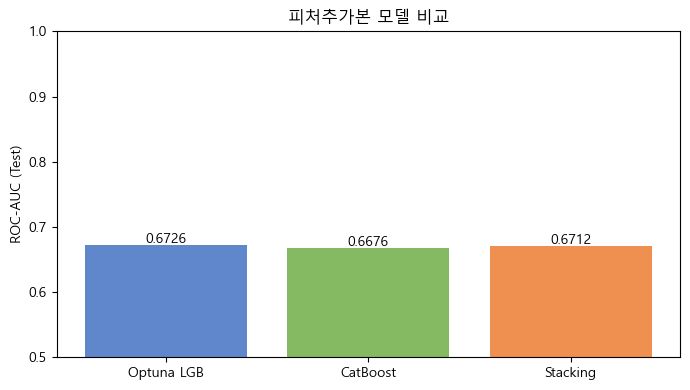


[피처추가본] Stacking 분류 리포트
              precision    recall  f1-score   support

          이탈       0.67      0.22      0.33      1185
         재결제       0.71      0.95      0.81      2370

    accuracy                           0.70      3555
   macro avg       0.69      0.58      0.57      3555
weighted avg       0.70      0.70      0.65      3555



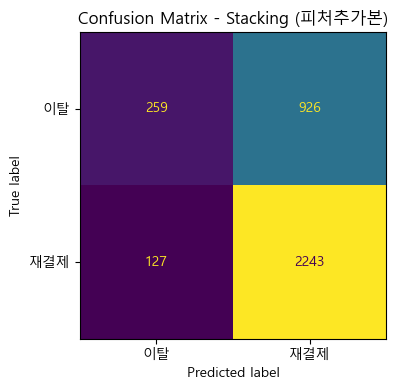

In [19]:
print(f"\n=== 피처추가본 최종 결과 ===")
opt_auc = next(r["LGB_AUC_Test"] for r in optuna_results if r["데이터셋"]=="피처추가본")
print(f"  Optuna LGB : AUC={opt_auc:.4f}")
print(f"  CatBoost   : AUC={cat_auc:.4f}")
print(f"  Stacking   : AUC={stk_auc:.4f}")

# 바차트
labels = ["Optuna LGB", "CatBoost", "Stacking"]
aucs   = [opt_auc, cat_auc, stk_auc]
colors = ["#4472C4", "#70AD47", "#ED7D31"]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, aucs, color=colors, alpha=0.85)
ax.set_ylim(0.5, 1.0); ax.set_ylabel("ROC-AUC (Test)")
ax.set_title("피처추가본 모델 비교")
for b, v in zip(bars, aucs):
    ax.text(b.get_x()+b.get_width()/2, v+0.003, f"{v:.4f}", ha="center", fontsize=10)
plt.tight_layout(); plt.show()

# Stacking Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
y_pred = stack.predict(Xv)
print("\n[피처추가본] Stacking 분류 리포트")
print(classification_report(yv_te, y_pred, target_names=["이탈","재결제"]))
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(yv_te, y_pred,
    display_labels=["이탈","재결제"], ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - Stacking (피처추가본)")
plt.tight_layout(); plt.show()

## 10. Optuna 200 trials - 전 모델 (피처추가본)


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from catboost import CatBoostClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 200

def obj_lr(trial):
    C = trial.suggest_float("C", 1e-3, 10.0, log=True)
    solver = trial.suggest_categorical("solver", ["lbfgs", "saga"])
    model = Pipeline([("sc", StandardScaler()),
                      ("lr", LogisticRegression(C=C, solver=solver, max_iter=1000, random_state=42))])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(model, Xv_tr, yv_tr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

def obj_rf(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 600),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        random_state=42, n_jobs=-1,
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(RandomForestClassifier(**params), Xv_tr, yv_tr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

def obj_gb(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 600),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 7),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        random_state=42,
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(GradientBoostingClassifier(**params), Xv_tr, yv_tr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

def obj_lgb(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 1000),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        num_leaves=trial.suggest_int("num_leaves", 20, 200),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 100),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        random_state=42, verbose=-1,
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(lgb.LGBMClassifier(**params), Xv_tr, yv_tr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

def obj_xgb(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 1000),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        gamma=trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        eval_metric="logloss", verbosity=0, random_state=42,
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(xgb.XGBClassifier(**params), Xv_tr, yv_tr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

def obj_cat(trial):
    params = dict(
        iterations=trial.suggest_int("iterations", 100, 800),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        depth=trial.suggest_int("depth", 3, 10),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        random_seed=42, verbose=0,
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(CatBoostClassifier(**params), Xv_tr, yv_tr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

def obj_et(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 600),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        random_state=42, n_jobs=-1,
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(ExtraTreesClassifier(**params), Xv_tr, yv_tr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

def obj_hgb(trial):
    params = dict(
        max_iter=trial.suggest_int("max_iter", 100, 800),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 10),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 10, 100),
        l2_regularization=trial.suggest_float("l2_regularization", 1e-6, 10.0, log=True),
        random_state=42,
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(HistGradientBoostingClassifier(**params), Xv_tr, yv_tr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

def build_lr(p):  return Pipeline([("sc", StandardScaler()), ("lr", LogisticRegression(C=p["C"], solver=p["solver"], max_iter=1000, random_state=42))])
def build_rf(p):  return RandomForestClassifier(**p, random_state=42, n_jobs=-1)
def build_gb(p):  return GradientBoostingClassifier(**p, random_state=42)
def build_lgb(p): return lgb.LGBMClassifier(**p, random_state=42, verbose=-1)
def build_xgb(p): return xgb.XGBClassifier(**p, random_state=42, eval_metric="logloss", verbosity=0)
def build_cat(p): return CatBoostClassifier(**p, random_seed=42, verbose=0)
def build_et(p):  return ExtraTreesClassifier(**p, random_state=42, n_jobs=-1)
def build_hgb(p): return HistGradientBoostingClassifier(**p, random_state=42)

optuna_jobs = [
    ("Logistic Regression",    obj_lr,  build_lr),
    ("Random Forest",          obj_rf,  build_rf),
    ("ExtraTrees",             obj_et,  build_et),
    ("Gradient Boosting",      obj_gb,  build_gb),
    ("HistGradientBoosting",   obj_hgb, build_hgb),
    ("LightGBM",               obj_lgb, build_lgb),
    ("XGBoost",                obj_xgb, build_xgb),
    ("CatBoost",               obj_cat, build_cat),
]

optuna200_results = []
for name, obj_fn, build_fn in optuna_jobs:
    print("튜닝 중:", name)
    study = optuna.create_study(direction="maximize")
    study.optimize(obj_fn, n_trials=N_TRIALS, show_progress_bar=True)
    model = build_fn(study.best_params)
    model.fit(Xv_tr, yv_tr)
    tr = calc_metrics(yv_tr, model.predict(Xv_tr), model.predict_proba(Xv_tr)[:,1])
    te = calc_metrics(yv_te, model.predict(Xv_te), model.predict_proba(Xv_te)[:,1])
    gap = tr["ROC-AUC"] - te["ROC-AUC"]
    flag = " << 과적합" if gap > 0.05 else ""
    print("  CV={:.4f}  Train={:.4f}  Test={:.4f}  Gap={:+.4f}{}".format(
          study.best_value, tr["ROC-AUC"], te["ROC-AUC"], gap, flag))
    optuna200_results.append({"name": name, "tr": tr, "te": te,
        "AUC": te["ROC-AUC"], "Gap": gap, "model": model, "CV": study.best_value,
        "Accuracy": te["Accuracy"], "F1": te["F1"],
        "Precision": te["Precision"], "Recall": te["Recall"],
        "PR_AUC": te["PR-AUC"], "Train_AUC": tr["ROC-AUC"],
    })

print()
print("="*80)
print(" Optuna 200 trials 결과 (피처추가본)")
print("="*80)
fmt_h = "  {:<22}  {:<6}  {:>8}  {:>8}  {:>9}  {:>7}  {:>7}  {:>7}"
fmt_r = "  {:<22}  {:<6}  {:>8.4f}  {:>8.4f}  {:>9.4f}  {:>7.4f}  {:>7.4f}  {:>7.4f}"
print(fmt_h.format("모델", "구분", "Accuracy", "F1", "Precision", "Recall", "ROC-AUC", "PR-AUC"))
print("  " + "-"*22 + "  " + "  ".join(["-"*6,"-"*8,"-"*8,"-"*9,"-"*7,"-"*7,"-"*7]))
for r in optuna200_results:
    gap = r["tr"]["ROC-AUC"] - r["te"]["ROC-AUC"]
    flag = " << 과적합" if gap > 0.05 else ""
    print(fmt_r.format(r["name"], "Train", r["tr"]["Accuracy"], r["tr"]["F1"], r["tr"]["Precision"], r["tr"]["Recall"], r["tr"]["ROC-AUC"], r["tr"]["PR-AUC"]))
    print(fmt_r.format("", "Test ", r["te"]["Accuracy"], r["te"]["F1"], r["te"]["Precision"], r["te"]["Recall"], r["te"]["ROC-AUC"], r["te"]["PR-AUC"])
          + "  Gap:{:+.4f}{}".format(gap, flag))
    print()

print("=== 기본 파라미터 vs Optuna 200 (Test ROC-AUC) ===")
base_aucs = {r["name"]: r["AUC"] for r in results_v2}
for r in optuna200_results:
    base = base_aucs.get(r["name"], 0)
    delta = r["te"]["ROC-AUC"] - base
    print("  {:<22}  기본={:.4f}  Optuna={:.4f}  ({:+.4f})".format(r["name"], base, r["te"]["ROC-AUC"], delta))

show_best_summary([
    ("원본",       results_raw),
    ("전처리본",   results_proc),
    ("피처추가본", results_v2),
    ("Optuna 200", optuna200_results),
])


튜닝 중: Logistic Regression


  0%|          | 0/200 [00:00<?, ?it/s]

  CV=0.6359  Train=0.6446  Test=0.6487  Gap=-0.0041
튜닝 중: Random Forest


  0%|          | 0/200 [00:00<?, ?it/s]

  CV=0.6540  Train=0.7905  Test=0.6733  Gap=+0.1172 << 과적합
튜닝 중: ExtraTrees


...

  CV=0.6591  Train=0.6982  Test=0.6755  Gap=+0.0228
튜닝 중: XGBoost


  0%|          | 0/200 [00:00<?, ?it/s]

  CV=0.6599  Train=0.7323  Test=0.6731  Gap=+0.0592 << 과적합
튜닝 중: CatBoost


  0%|          | 0/200 [00:00<?, ?it/s]

  CV=0.6588  Train=0.7075  Test=0.6785  Gap=+0.0291

 Optuna 200 trials 결과 (피처추가본)
  모델                      구분      Accuracy        F1  Precision   Recall  ROC-AUC   PR-AUC
  ----------------------  ------  --------  --------  ---------  -------  -------  -------
  Logistic Regression     Train     0.6877    0.8030     0.6928   0.9548   0.6446   0.7627
                          Test      0.6948    0.8077     0.6963   0.9616   0.6487   0.7652  Gap:-0.0041

  Random Forest           Train     0.7088    0.8191     0.6990   0.9888   0.7905   0.8787
                          Test      0.6934    0.8104     0.6895   0.9827   0.6733   0.7811  Gap:+0.1172 << 과적합

  ExtraTrees              Train     0.7144    0.8215     0.7040   0.9861   0.7908   0.8846
                          Test      0.6965    0.8107     0.6939   0.9747   0.6688   0.7799  Gap:+0.1221 << 과적합

  Gradient Boosting       Train     0.7152    0.8216     0.7052   0.9840   0.7684   0.8587
                          Test      0.6965

## 11. Optuna 200 Best Model - Feature Importance


Best Model: CatBoost   Test ROC-AUC=0.6785


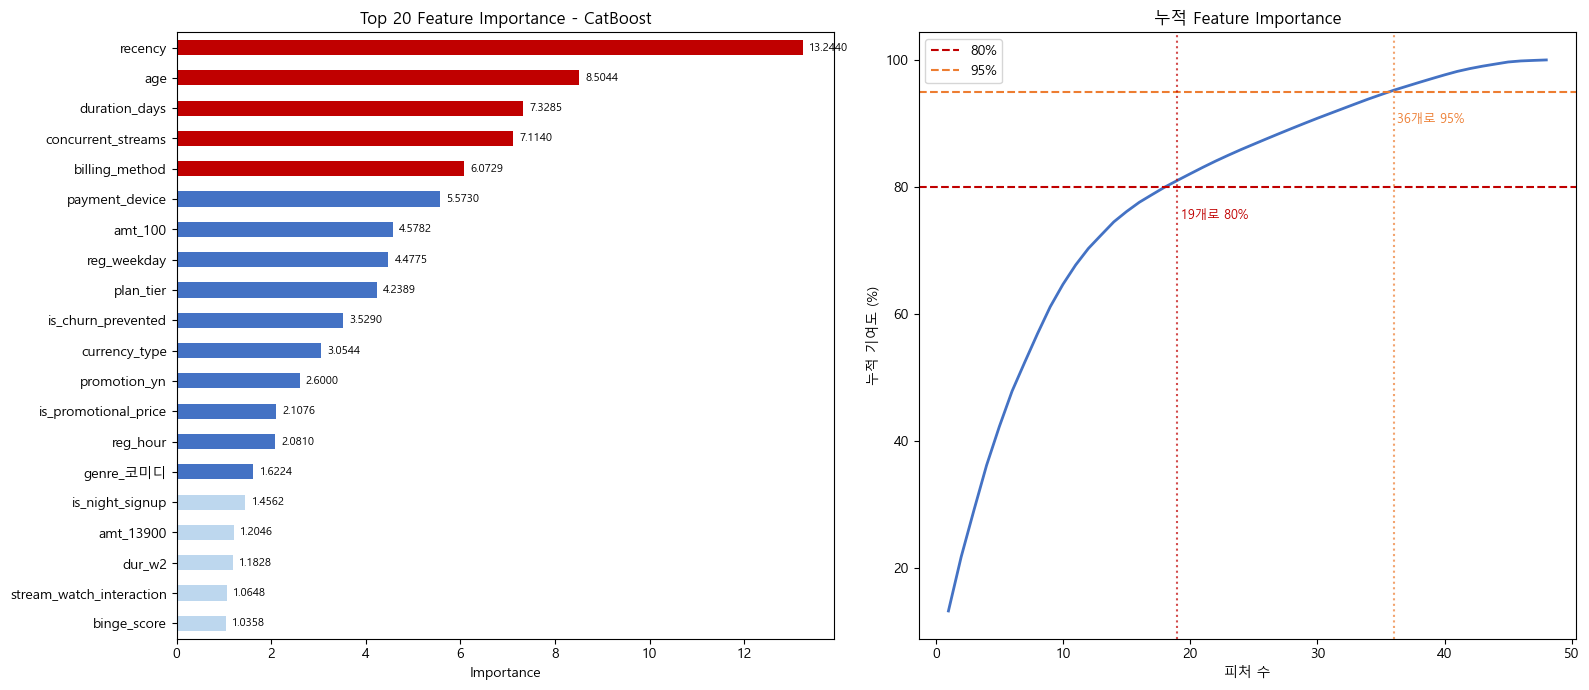


Top 10 피처:
   1. recency                         13.2440
   2. age                             8.5044
   3. duration_days                   7.3285
   4. concurrent_streams              7.1140
   5. billing_method                  6.0729
   6. payment_device                  5.5730
   7. amt_100                         4.5782
   8. reg_weekday                     4.4775
   9. plan_tier                       4.2389
  10. is_churn_prevented              3.5290


In [21]:
# ── Optuna 200 Best Model Feature Importance ────────
best_opt = max(optuna200_results, key=lambda r: r["AUC"])
best_model = best_opt["model"]
best_name  = best_opt["name"]
print("Best Model:", best_name, "  Test ROC-AUC={:.4f}".format(best_opt["AUC"]))

# Pipeline이면 마지막 estimator 추출
estimator = best_model
if hasattr(best_model, "named_steps"):
    estimator = list(best_model.named_steps.values())[-1]

feat_cols = Xv_te.columns.tolist()

if hasattr(estimator, "feature_importances_"):
    fi = pd.Series(estimator.feature_importances_, index=feat_cols).sort_values(ascending=False)
elif hasattr(estimator, "coef_"):
    fi = pd.Series(np.abs(estimator.coef_[0]), index=feat_cols).sort_values(ascending=False)
else:
    fi = None

if fi is not None:
    top_n = 20
    fi_top = fi.head(top_n).sort_values(ascending=True)
    colors = ["#C00000" if v >= fi_top.quantile(0.75) else
              "#4472C4" if v >= fi_top.quantile(0.25) else "#BDD7EE"
              for v in fi_top.values]
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # 좌: Top 20 바차트
    fi_top.plot(kind="barh", ax=axes[0], color=colors)
    axes[0].set_title("Top 20 Feature Importance - " + best_name)
    axes[0].set_xlabel("Importance")
    for i, (v, name_f) in enumerate(zip(fi_top.values, fi_top.index)):
        axes[0].text(v + fi_top.max()*0.01, i, "{:.4f}".format(v), va="center", fontsize=8)

    # 우: 전체 누적 기여도
    fi_sorted = fi.sort_values(ascending=False)
    cumsum = fi_sorted.cumsum() / fi_sorted.sum() * 100
    axes[1].plot(range(1, len(cumsum)+1), cumsum.values, color="#4472C4", linewidth=2)
    axes[1].axhline(80, color="#C00000", linestyle="--", label="80%")
    axes[1].axhline(95, color="#ED7D31", linestyle="--", label="95%")
    n80 = (cumsum <= 80).sum() + 1
    n95 = (cumsum <= 95).sum() + 1
    axes[1].axvline(n80, color="#C00000", linestyle=":", alpha=0.7)
    axes[1].axvline(n95, color="#ED7D31", linestyle=":", alpha=0.7)
    axes[1].set_xlabel("피처 수")
    axes[1].set_ylabel("누적 기여도 (%)")
    axes[1].set_title("누적 Feature Importance")
    axes[1].legend()
    axes[1].text(n80+0.3, 75, "{}개로 80%".format(n80), color="#C00000", fontsize=9)
    axes[1].text(n95+0.3, 90, "{}개로 95%".format(n95), color="#ED7D31", fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\nTop 10 피처:")
    for i, (feat, val) in enumerate(fi.head(10).items(), 1):
        print("  {:>2}. {:<30}  {:.4f}".format(i, feat, val))
else:
    print(best_name, "은 feature_importances_ 미지원")


## 12. 다중공선성 (VIF) 분석

In [1]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

# v2 데이터 기준 VIF 계산
df_vif = pd.read_csv("../data/Membership_processing.csv")
drop_c = ["user_no","reg_date","end_date","product_cd","repurchase"]
df_vif = df_vif.drop(columns=[c for c in drop_c if c in df_vif.columns])
for col in df_vif.select_dtypes(include="object").columns:
    df_vif[col] = LabelEncoder().fit_transform(df_vif[col].astype(str))
df_vif = df_vif.dropna()

# VIF 계산
vif_data = pd.DataFrame({
    "Feature": df_vif.columns,
    "VIF":     [variance_inflation_factor(df_vif.values, i)
                for i in range(df_vif.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("=" * 55)
print(" 다중공선성 (VIF) 분석 결과")
print("=" * 55)
print(f"{'피처':<28} {'VIF':>8}  판정")
print("-" * 55)
for _, row in vif_data.iterrows():
    v = row["VIF"]
    judge = "<< 심각 (제거 고려)" if v >= 10 else "<< 주의" if v >= 5 else ""
    print(f"{row['Feature']:<28} {v:>8.2f}  {judge}")

print()
high = vif_data[vif_data["VIF"] >= 10]
mid  = vif_data[(vif_data["VIF"] >= 5) & (vif_data["VIF"] < 10)]
low  = vif_data[vif_data["VIF"] < 5]
print(f"VIF >= 10 (심각): {len(high)}개  {list(high['Feature'])}")
print(f"VIF  5~10 (주의): {len(mid)}개  {list(mid['Feature'])}")
print(f"VIF  <  5 (정상): {len(low)}개")


c:\Users\USER\anaconda4\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


 다중공선성 (VIF) 분석 결과
피처                                VIF  판정
-------------------------------------------------------
promotion_yn                      inf  << 심각 (제거 고려)
is_promotional_price              inf  << 심각 (제거 고려)
age                            193.38  << 심각 (제거 고려)
age_group                      165.36  << 심각 (제거 고려)
duration_days                  134.26  << 심각 (제거 고려)
billing_method                  61.04  << 심각 (제거 고려)
amount                          34.52  << 심각 (제거 고려)
total_watch_count               22.73  << 심각 (제거 고려)
unique_movies                   13.75  << 심각 (제거 고려)
has_watch_history               12.68  << 심각 (제거 고려)
watch_days_count                11.02  << 심각 (제거 고려)
total_watch_duration             9.60  << 주의
is_user_verified                 7.58  << 주의
avg_duration                     6.08  << 주의
concurrent_streams               5.87  << 주의
reg_hour                         4.80  
reg_weekday                      2.95  
is_same_day_cancel               2.52  


### VIF 시각화

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(font='Malgun Gothic', rc={'axes.unicode_minus': False})

numeric_cols = [
    'amount', 'billing_method', 'concurrent_streams', 'promotion_yn',
    'is_churn_prevented', 'is_user_verified', 'gender', 'age',
    'reg_hour', 'duration_days', 'is_promotional_price', 'is_night_signup',
    'reg_weekday', 'is_same_day_cancel', 'age_group',
]

corr_matrix = df_vif[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('수치형 피처 간 상관계수 행렬 (Membership_processing 기준)', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# |0.7| 이상 상관쌍 출력
print("\n[ |상관계수| >= 0.7 인 쌍 ]")
high_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack().reset_index()
)
high_corr.columns = ['col1', 'col2', 'corr']
high_corr = high_corr[high_corr['corr'].abs() >= 0.7].sort_values('corr', ascending=False)
print(high_corr.to_string(index=False) if not high_corr.empty else "해당 없음")


## 13. 이탈 고위험군 프로파일링

In [5]:
import matplotlib.pyplot as plt
import matplotlib
import warnings; warnings.filterwarnings("ignore")
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd, numpy as np
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# v2 데이터 로드 + 전처리
df_v2 = pd.read_csv("../data/Membership_v2.csv")
drop  = ["user_no","reg_date","end_date","product_cd"]
feat  = [c for c in df_v2.columns if c not in drop + ["repurchase"]]
X = df_v2[feat].copy()
for c in X.select_dtypes(include="object").columns:
    X[c] = LabelEncoder().fit_transform(X[c].astype(str))
y = df_v2["repurchase"]

Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# CatBoost 빠른 학습 (기본 파라미터 — 프로파일링 목적)
model_hr = CatBoostClassifier(iterations=500, learning_rate=0.05,
                               depth=6, random_seed=42, verbose=0)
model_hr.fit(Xv_tr, yv_tr)

from sklearn.metrics import roc_auc_score
auc = roc_auc_score(yv_te, model_hr.predict_proba(Xv_te)[:,1])
print(f"CatBoost Test AUC = {auc:.4f}")

# 이탈 확률 계산
prob_churn = model_hr.predict_proba(Xv_te)[:, 0]  # 0 = 이탈 클래스
df_risk = Xv_te.copy()
df_risk["churn_prob"] = prob_churn
df_risk["actual"]     = yv_te.values

# 고위험군 정의: 이탈 확률 상위 30%
threshold = df_risk["churn_prob"].quantile(0.70)
df_risk["risk_group"] = (df_risk["churn_prob"] >= threshold).map({True:"고위험군", False:"저위험군"})

high = df_risk[df_risk["risk_group"] == "고위험군"]
low  = df_risk[df_risk["risk_group"] == "저위험군"]

print(f"고위험군: {len(high)}명  |  저위험군: {len(low)}명")
print(f"고위험군 실제 이탈률: {(high['actual']==0).mean():.1%}")
print(f"저위험군 실제 이탈률: {(low['actual']==0).mean():.1%}")
print(f"이탈 확률 임계값: {threshold:.3f}")

CatBoost Test AUC = 0.6750
고위험군: 1067명  |  저위험군: 2488명
고위험군 실제 이탈률: 51.9%
저위험군 실제 이탈률: 25.4%
이탈 확률 임계값: 0.375


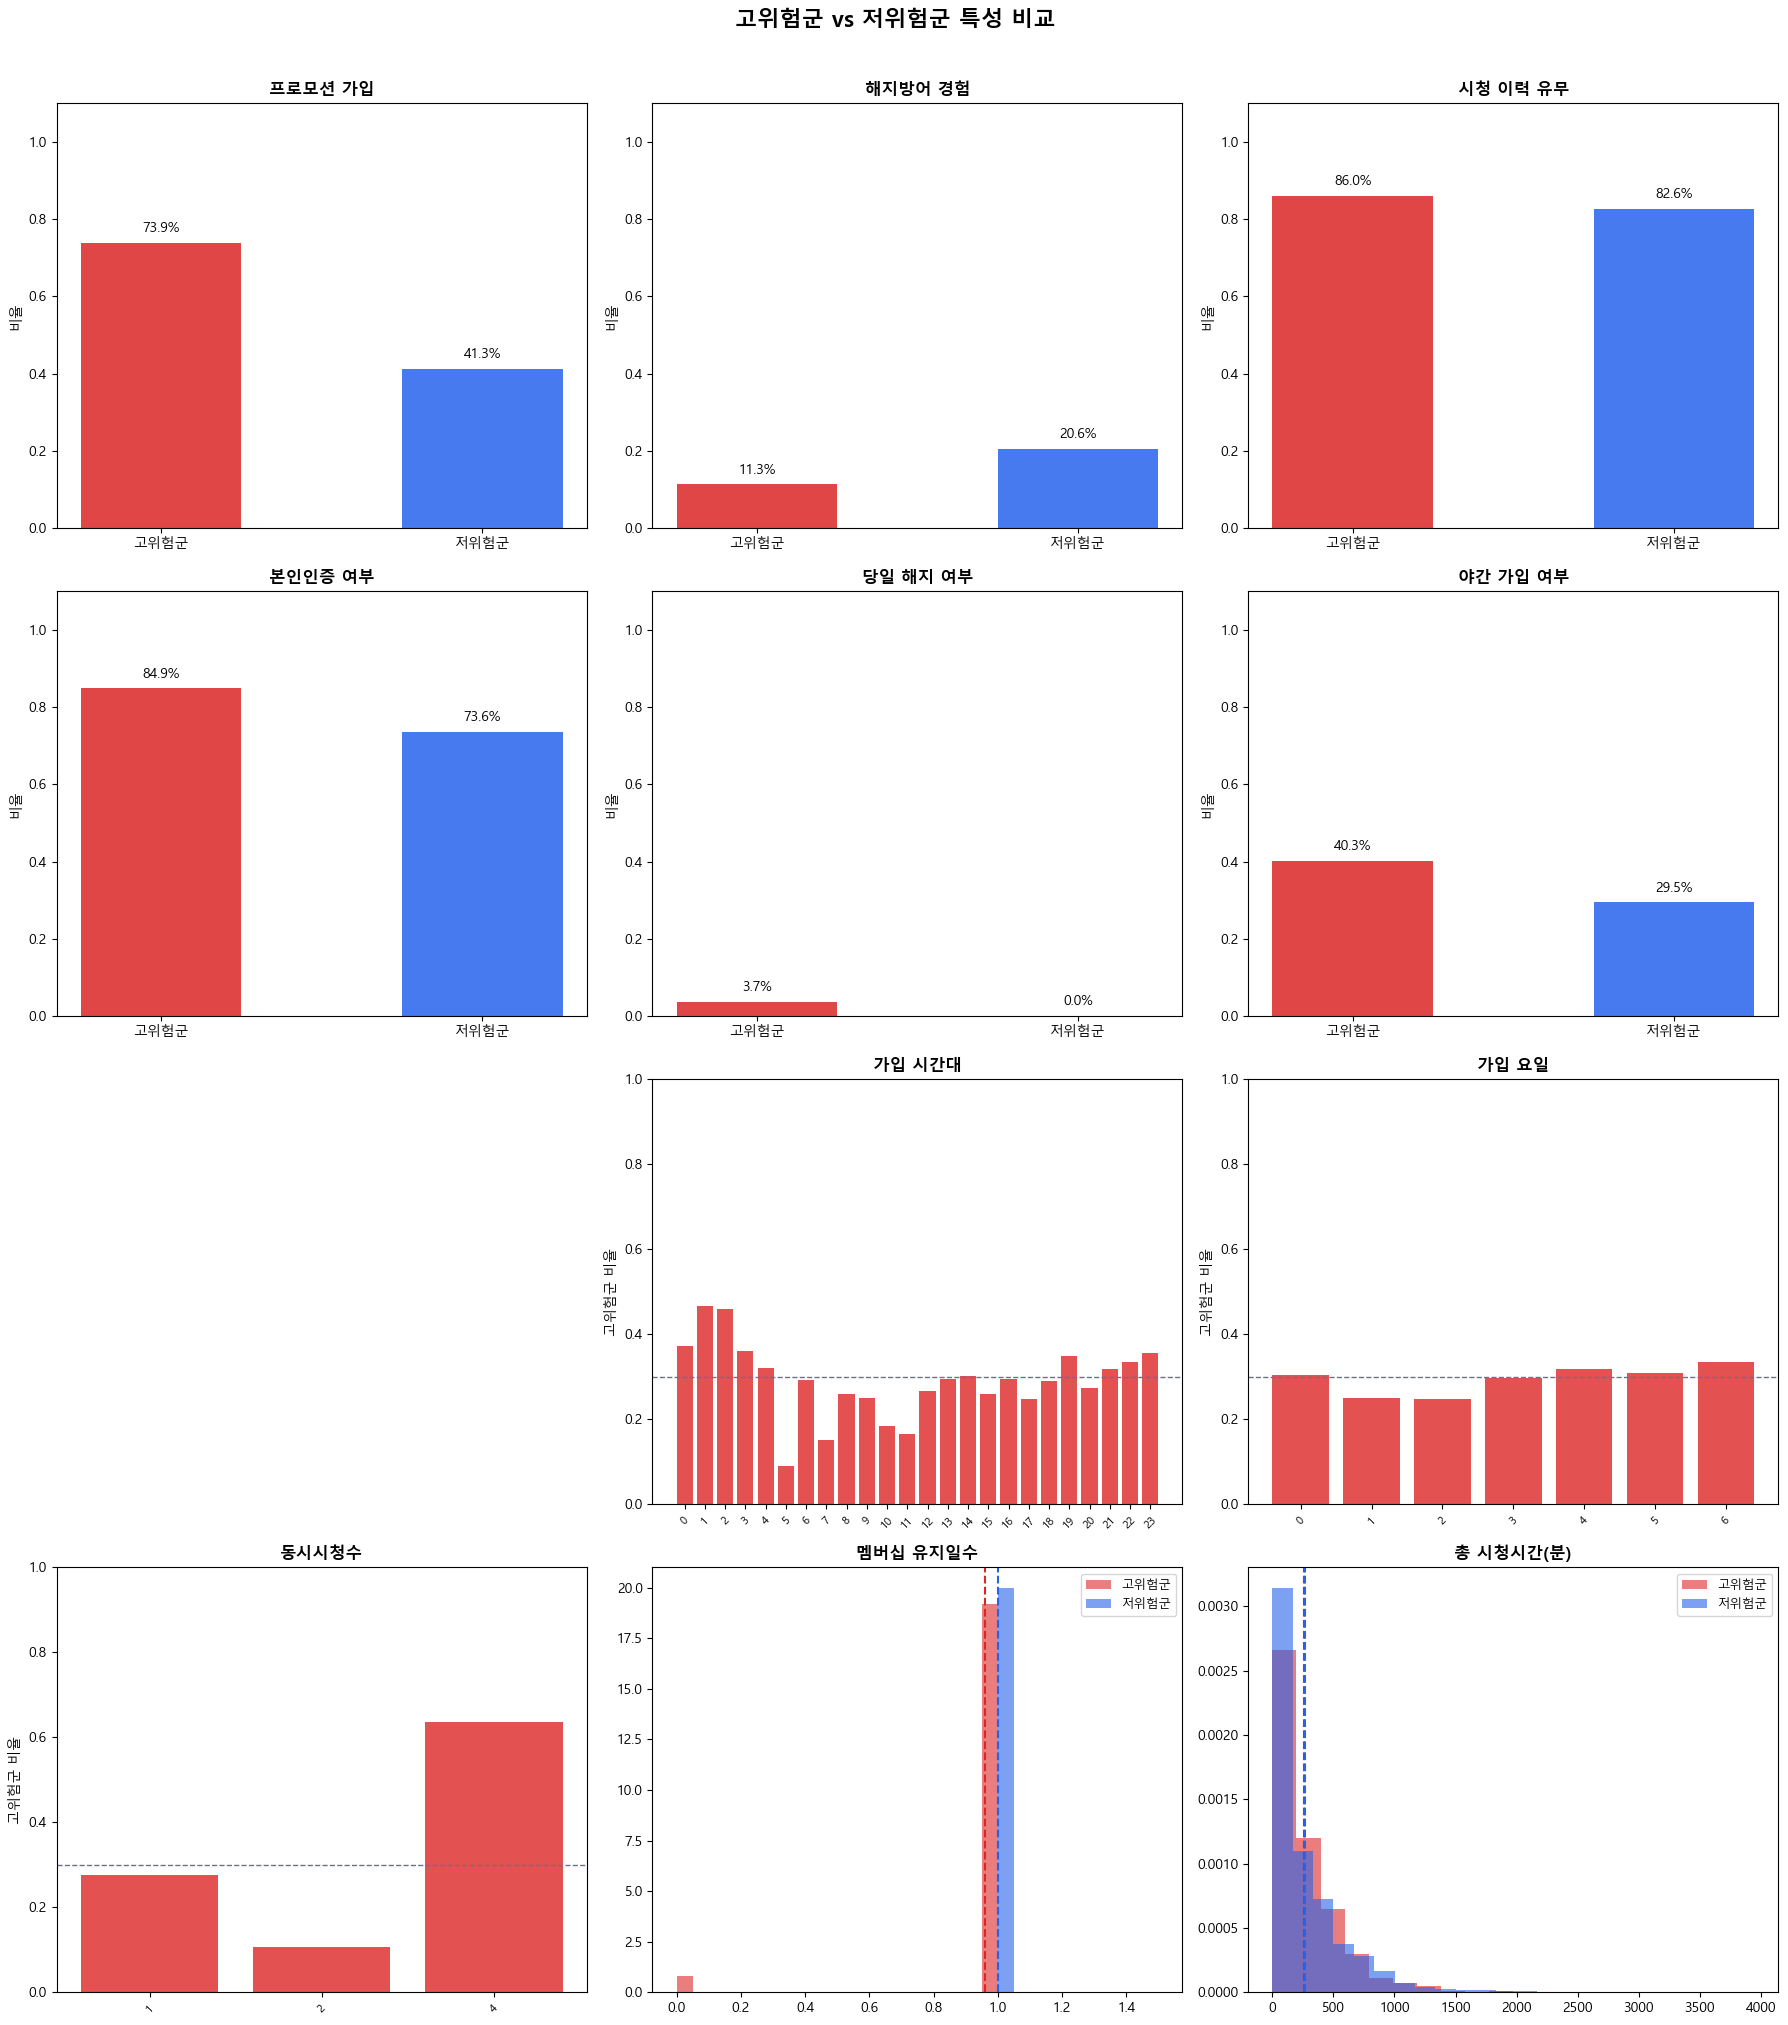

In [8]:
features = {
    "promotion_yn":        ("프로모션 가입",   "bar"),
    "is_churn_prevented":  ("해지방어 경험",   "bar"),
    "has_watch_history":   ("시청 이력 유무",  "bar"),
    "is_user_verified":    ("본인인증 여부",   "bar"),
    "is_same_day_cancel":  ("당일 해지 여부",  "bar"),
    "is_night_signup":     ("야간 가입 여부",  "bar"),
    "age_group":           ("연령대",          "age_bar"),
    "reg_hour":            ("가입 시간대",      "bar_all"),
    "reg_weekday":         ("가입 요일",        "bar_all"),
    "concurrent_streams":  ("동시시청수",       "bar_all"),
    "duration_days":       ("멤버십 유지일수",  "hist"),
    "total_watch_duration":("총 시청시간(분)",  "hist"),
}

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.ravel()

for idx, (feat, (label, chart_type)) in enumerate(features.items()):
    ax = axes[idx]
    if feat not in df_risk.columns:
        ax.set_visible(False)
        continue

    if chart_type == "bar":
        h_val = high[feat].mean()
        l_val = low[feat].mean()
        bars = ax.bar(["고위험군", "저위험군"], [h_val, l_val],
                      color=["#DC2626", "#2563EB"], alpha=0.85, width=0.5)
        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.set_ylabel("비율")
        ax.set_ylim(0, 1.1)
        for bar, v in zip(bars, [h_val, l_val]):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                    "{:.1%}".format(v), ha="center", va="bottom", fontsize=10)

    elif chart_type == "age_bar":
        # 연령대별 고위험/저위험 비율 — 빈 구간 없는 바차트
        age_bins = sorted(df_risk[feat].dropna().unique().astype(int))
        h_counts = high[feat].value_counts().reindex(age_bins, fill_value=0)
        l_counts = low[feat].value_counts().reindex(age_bins, fill_value=0)
        h_ratio  = h_counts / (h_counts + l_counts).replace(0, 1)
        x = range(len(age_bins))
        ax.bar(x, h_ratio.values, color="#DC2626", alpha=0.85, label="고위험군 비율")
        ax.set_xticks(list(x))
        ax.set_xticklabels(["{}대".format(a) for a in age_bins], fontsize=9)
        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.set_ylabel("고위험군 비율")
        ax.set_ylim(0, 1.0)
        ax.axhline(0.3, color="#6B7280", linestyle="--", linewidth=1, label="전체 평균(30%)")
        ax.legend(fontsize=8)

    elif chart_type == "bar_all":
        vals = sorted(df_risk[feat].dropna().unique())
        h_cnt = high[feat].value_counts().reindex(vals, fill_value=0)
        l_cnt = low[feat].value_counts().reindex(vals, fill_value=0)
        ratio = h_cnt / (h_cnt + l_cnt).replace(0, 1)
        x = range(len(vals))
        ax.bar(x, ratio.values, color="#DC2626", alpha=0.8)
        ax.set_xticks(list(x))
        ax.set_xticklabels([str(v) for v in vals], fontsize=8, rotation=45)
        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.set_ylabel("고위험군 비율")
        ax.set_ylim(0, 1.0)
        ax.axhline(0.3, color="#6B7280", linestyle="--", linewidth=1)

    else:
        ax.hist(high[feat].dropna(), bins=20, alpha=0.6,
                color="#DC2626", label="고위험군", density=True)
        ax.hist(low[feat].dropna(),  bins=20, alpha=0.6,
                color="#2563EB", label="저위험군", density=True)
        ax.axvline(high[feat].mean(), color="#DC2626", linestyle="--", linewidth=1.5)
        ax.axvline(low[feat].mean(),  color="#2563EB", linestyle="--", linewidth=1.5)
        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)

plt.suptitle("고위험군 vs 저위험군 특성 비교", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [7]:

binary_feats = ["promotion_yn","is_churn_prevented","has_watch_history",
                "is_user_verified","is_same_day_cancel","is_night_signup"]
cont_feats   = ["age","duration_days","total_watch_duration","total_watch_count","reg_hour"]

print("=" * 60)
print(" 고위험군 vs 저위험군 수치 비교")
print("=" * 60)
print("  {:<24} {:>8} {:>8} {:>8}".format("피처", "고위험군", "저위험군", "차이"))
print("  " + "-" * 56)

for feat in binary_feats:
    if feat not in df_risk.columns:
        continue
    h = high[feat].mean()
    l = low[feat].mean()
    print("  {:<24} {:>7.1%}  {:>7.1%}  {:>+7.1%}".format(feat, h, l, h - l))

print()
for feat in cont_feats:
    if feat not in df_risk.columns:
        continue
    h = high[feat].mean()
    l = low[feat].mean()
    print("  {:<24} {:>8.1f} {:>8.1f} {:>+8.1f}".format(feat, h, l, h - l))

print()
print("=" * 60)
print(" 이탈 고위험군 프로파일 요약")
print("=" * 60)

if "plan_tier" in df_risk.columns:
    print("")
    print("[플랜별 고위험군 비율]")
    plan_risk = df_risk.groupby("plan_tier")["risk_group"].apply(
        lambda x: (x == "고위험군").mean()
    ).sort_values(ascending=False)
    for plan, ratio in plan_risk.items():
        print("  {}: {:.1%}".format(plan, ratio))

if "billing_method" in df_risk.columns:
    print("")
    print("[결제수단별 고위험군 비율]")
    bill_risk = df_risk.groupby("billing_method")["risk_group"].apply(
        lambda x: (x == "고위험군").mean()
    ).sort_values(ascending=False)
    for b, ratio in bill_risk.head(5).items():
        print("  billing_method {}: {:.1%}".format(b, ratio))

if "age_group" in df_risk.columns:
    print("")
    print("[연령대별 고위험군 비율]")
    age_risk = df_risk.groupby("age_group")["risk_group"].apply(
        lambda x: (x == "고위험군").mean()
    ).sort_values(ascending=False)
    for age, ratio in age_risk.items():
        print("  {}대: {:.1%}".format(age, ratio))


 고위험군 vs 저위험군 수치 비교
  피처                           고위험군     저위험군       차이
  --------------------------------------------------------
  promotion_yn               73.9%    41.3%   +32.7%
  is_churn_prevented         11.3%    20.6%    -9.3%
  has_watch_history          86.0%    82.6%    +3.4%
  is_user_verified           84.9%    73.6%   +11.3%
  is_same_day_cancel          3.7%     0.0%    +3.7%
  is_night_signup            40.3%    29.5%   +10.8%

  age                          27.9     34.1     -6.2
  duration_days                 1.0      1.0     -0.0
  total_watch_duration        258.6    264.4     -5.7
  total_watch_count             6.0      5.8     +0.2
  reg_hour                     13.4     13.7     -0.3

 이탈 고위험군 프로파일 요약

[플랜별 고위험군 비율]
  1: 63.8%
  0: 28.1%
  3: 10.9%
  2: 10.6%

[결제수단별 고위험군 비율]
  billing_method 190: 59.5%
  billing_method 180: 55.8%
  billing_method 170: 40.5%
  billing_method 140: 30.4%
  billing_method 132: 27.0%
